<a href="https://colab.research.google.com/github/Pameta1/TelecomX_2/blob/main/TelecomX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preparación de los datos


✔   Limpieza

✔   Encoding

✔   Normalización






In [1]:
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
datos_cliente = pd.read_csv('/content/datos_tratados.csv')

In [4]:
datos_cliente.head(2)

,CustomerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_bin,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,0.0,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,0.0,1.996667


#### Eliminación de Columnas

In [5]:
columnas_a_eliminar = ['CustomerID', 'Churn']

In [6]:
datos_cliente = datos_cliente.drop(columns=['CustomerID', 'Churn'])

In [7]:
datos_cliente.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_bin,Cuentas_Diarias
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,0.0,2.186667
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,0.0,1.996667


In [8]:
datos_cliente.rename(columns={                      # Renombrar columnas para mayor claridad
    'Churn_bin':'Cancelaciones'
}, inplace=True)

In [9]:
datos_cliente.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cancelaciones,Cuentas_Diarias
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,0.0,2.186667


#### Gestión de limpieza de datos numéricos

In [10]:
cols_num = ['MonthlyCharges', 'TotalCharges', 'Cuentas_Diarias', 'Cancelaciones']

for col in cols_num:
    datos_cliente[col] = (
        datos_cliente[col]
        .astype(str)      # asegurar que es string
        .str.strip()      # eliminar espacios
        .replace('', None)  # convertir vacío en NaN real
    )

In [11]:
for col in cols_num:
    datos_cliente[col] = pd.to_numeric(datos_cliente[col], errors='coerce')

In [12]:
for col in cols_num:
    try:
        datos_cliente[col].astype(float)
        print(f"{col} OK")
    except:
        print(f"{col} tiene problema")

MonthlyCharges OK
TotalCharges OK
Cuentas_Diarias OK
Cancelaciones OK


In [13]:
datos_cliente_corr = datos_cliente[cols_num].dropna()
datos_cliente_corr.corr()

,MonthlyCharges,TotalCharges,Cuentas_Diarias,Cancelaciones
MonthlyCharges,1.000000,0.651065,1.000000,0.192858
TotalCharges,0.651065,1.000000,0.651065,-0.199484
Cuentas_Diarias,1.000000,0.651065,1.000000,0.192858
Cancelaciones,0.192858,-0.199484,0.192858,1.000000


In [14]:
datos_cliente['Cancelaciones'].isna().sum()

np.int64(224)

In [15]:
datos_cliente = datos_cliente.dropna(subset=['Cancelaciones'])

In [16]:
# Separar X e y
X = datos_cliente.drop('Cancelaciones', axis=1)
y = datos_cliente['Cancelaciones']

In [17]:
# Separar variables predictoras y objetivo
X = datos_cliente.drop('Cancelaciones', axis=1)
y = datos_cliente['Cancelaciones']

Se identificaron 11 valores faltantes en la variable TotalCharges, asociados a clientes con antigüedad (tenure) igual a cero. Debido a que representan una proporción mínima del dataset, estos registros fueron eliminados para evitar inconsistencias durante el entrenamiento de los modelos.

In [18]:
datos_cliente = datos_cliente.dropna(subset=['TotalCharges'])

In [19]:
X = datos_cliente.drop('Cancelaciones', axis=1)
y = datos_cliente['Cancelaciones']

In [20]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [21]:
print("NaN en X:", X_encoded.isna().sum().sum())
print("NaN en y:", y.isna().sum())

NaN en X: 0
NaN en y: 0


## Encoding

In [22]:
# Dividir train-test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [23]:
 # Pipeline de preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Identificar columnas
columnas_numericas = X.select_dtypes(include=['int64','float64']).columns
columnas_categoricas = X.select_dtypes(include=['object']).columns

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), columnas_categoricas)
    ]
)

In [24]:
# Aplicar One_Hot Encoding
X_encoded = pd.get_dummies(X,drop_first=True)

print(X_encoded.shape)

(7032, 31)


In [25]:
X.select_dtypes(include=['object']).columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_log = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000))
])

pipeline_log.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Cuentas_Diarias'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('modelo', LogisticRegression(max_iter=1000))])

## Verificación de la proporción de cancelación (Churn)

#### Primero calculamos cuántos clientes cancelaron y los que  no cancelaron

In [27]:
datos_cliente['Cancelaciones'].value_counts()

,count
Cancelaciones,
0.0,5163
1.0,1869




*   0 = cliente activo
*   1 = cliente canceló



#### Proporción (porcentaje)

In [28]:
(datos_cliente['Cancelaciones'].value_counts(normalize=True) * 100).round(2)

,proportion
Cancelaciones,
0.0,73.42
1.0,26.58


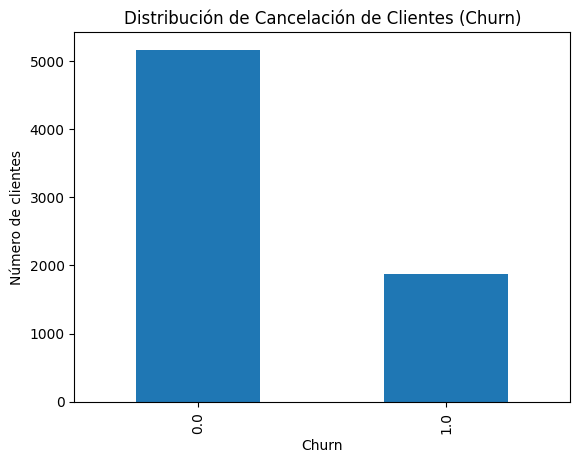

In [29]:
import matplotlib.pyplot as plt

datos_cliente['Cancelaciones'].value_counts().plot(
    kind='bar',
    title='Distribución de Cancelación de Clientes (Churn)',
)

plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.show()

#### Interpretación

El análisis de la variable objetivo muestra que aproximadamente 73% de los clientes permanecen activos, mientras que cerca del 27% han cancelado el servicio.
Esto indica un desbalance moderado entre las clases, lo cual es común en problemas de churn y debe considerarse al evaluar el desempeño de los modelos predictivos.

## Balanceo de Clases Técnica SMOTE

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_bal, y_bal = smote.fit_resample(X_encoded, y)

In [31]:
y_bal.value_counts()

,count
Cancelaciones,
0.0,5163
1.0,5163


Debido al desbalance existente entre clientes que cancelan y aquellos que permanecen activos, se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique) para generar ejemplos sintéticos de la clase minoritaria. Esto permite entrenar modelos más equilibrados y mejorar la capacidad de detectar clientes con riesgo de cancelación.

## Normalización /estandarización

#### Aplicar estandireación con StandarScaler

In [32]:
# Identificación de variables numéricas
from sklearn.preprocessing import StandardScaler

columnas_numericas = ['tenure','MonthlyCharges','TotalCharges','Cuentas_Diarias']

In [33]:
scaler = StandardScaler()

X_encoded[columnas_numericas] = scaler.fit_transform(X_encoded[columnas_numericas])

In [34]:
X_encoded[columnas_numericas].describe()

,tenure,MonthlyCharges,TotalCharges,Cuentas_Diarias
count,7.032000e+03,7.032000e+03,7.032000e+03,7.032000e+03
mean,-1.111486e-16,5.860563e-17,8.285623e-17,7.729880e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.280248e+00,-1.547283e+00,-9.990692e-01,-1.547283e+00
25%,-9.542963e-01,-9.709769e-01,-8.302488e-01,-9.709769e-01
50%,-1.394171e-01,1.845440e-01,-3.908151e-01,1.845440e-01
75%,9.199259e-01,8.331482e-01,6.668271e-01,8.331482e-01
max,1.612573e+00,1.793381e+00,2.824261e+00,1.793381e+00


Se aplicó estandarización mediante StandardScaler a las variables numéricas para garantizar que todas tengan media cero y desviación estándar uno. Este paso es necesario para modelos sensibles a la escala de los datos, como Regresión Logística, evitando que variables con magnitudes mayores influyan desproporcionadamente en el modelo.

## Correlación y Selección de Variables

#### Seleccionar sólo variables numéricas

In [35]:
variables_numericas = datos_cliente.select_dtypes(include=['int64','float64'])

variables_numericas.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Cancelaciones,Cuentas_Diarias
0,0,9,65.6,593.30,0.0,2.186667
1,0,9,59.9,542.40,0.0,1.996667
2,0,4,73.9,280.85,1.0,2.463333
3,1,13,98.0,1237.85,1.0,3.266667
4,1,3,83.9,267.40,1.0,2.796667


#### Calcular matriz de correlación

Esto calcula la correlación de Pearson entre todas las variables numéricas:

Estos van de valor 1 correlación positiva perfecta.

✔ valor 0 hay correlación

✔ valor -1 correlación negativa perfecta

In [36]:
matriz_corr = variables_numericas.corr()
matriz_corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Cancelaciones,Cuentas_Diarias
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541,0.219874
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049,0.246862
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858,1.000000
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484,0.651065
Cancelaciones,0.150541,-0.354049,0.192858,-0.199484,1.000000,0.192858
Cuentas_Diarias,0.219874,0.246862,1.000000,0.651065,0.192858,1.000000


#### Visualizar matriz con Heatman

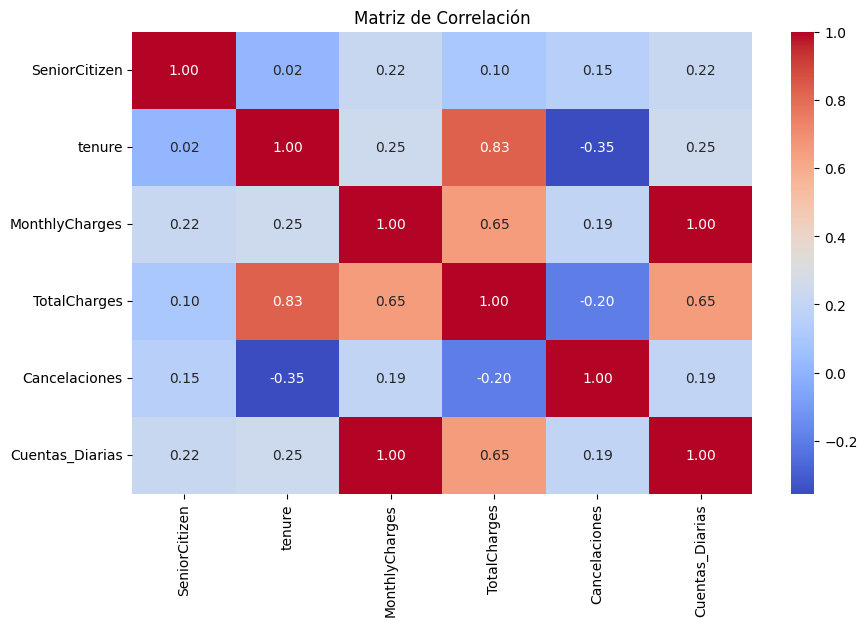

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"                       # 1 correlación positiva perfecah
)                                   # 0 no hay relación
                                    # -1 correlación negativa perfecta
plt.title("Matriz de Correlación")
plt.show()

####Correlación específica con Churn

In [38]:
matriz_corr['Cancelaciones'].sort_values(ascending=False)

,Cancelaciones
Cancelaciones,1.000000
Cuentas_Diarias,0.192858
MonthlyCharges,0.192858
SeniorCitizen,0.150541
TotalCharges,-0.199484
tenure,-0.354049


#### Interpretación típica en churn

**Tenure** (-0.354)

Es la correlación negativa más fuerte con la cancelación.

✔ Clientes con más tiempo en la empresa cancelan menos
✔ Clientes nuevos cancelan más

Esto es muy común en análisis de churn porque los clientes recién adquiridos aún no están fidelizados.

**TotalCharges** (-0.199)

Tiene correlación negativa débil.

✔ Clientes con mayor gasto total tienden a cancelar menos
✔ Probablemente porque son clientes antiguos

Esto tiene relación directa con **tenure**, ya que mientras más tiempo esté un cliente, más dinero acumula en gastos.

**MonthlyCharges** (0.192)

Tiene una correlación positiva débil.

✔ Clientes con cargos mensuales más altos tienen mayor probabilidad de cancelar.

✔ Percepción de precio alto
✔ Comparación con competidores

**Cuentas_Diarias** (0.192)

Tiene exactamente la misma correlación que MonthlyCharges.

✔ A mayor costo o frecuencia de facturación, mayor probabilidad de churn.

**SeniorCitizen** (0.150)

Tiene una correlación positiva débil.

✔ Los clientes mayores presentan ligeramente mayor probabilidad de cancelación.

Pero el impacto no es fuerte, por lo que no es un factor determinante.

##Identificación de variables importantes

####Variables con mayor correlación absoluta con **Cancelaciones** son buenas candidatas para el modelo

In [39]:
corr_churn = matriz_corr['Cancelaciones'].abs().sort_values(ascending=False)

corr_churn

,Cancelaciones
Cancelaciones,1.000000
tenure,0.354049
TotalCharges,0.199484
Cuentas_Diarias,0.192858
MonthlyCharges,0.192858
SeniorCitizen,0.150541


In [40]:
corr_churn[1:10]  #Se quita la correlación consigo mismo

,Cancelaciones
tenure,0.354049
TotalCharges,0.199484
Cuentas_Diarias,0.192858
MonthlyCharges,0.192858
SeniorCitizen,0.150541


####Interpretación

Se analizó la matriz de correlación entre las variables numéricas del dataset.

Se observó que variables como **tenure**, **MonthlyCharges** y **TotalCharges** presentan una relación relevante con la cancelación de clientes.

En particular, la variable **tenure** muestra una correlación negativa con el churn, indicando que los clientes con mayor antigüedad tienden a cancelar menos sus servicios.

####Análisis Dirigido

####Tiempo de contrato (tenure) vs Cancelación

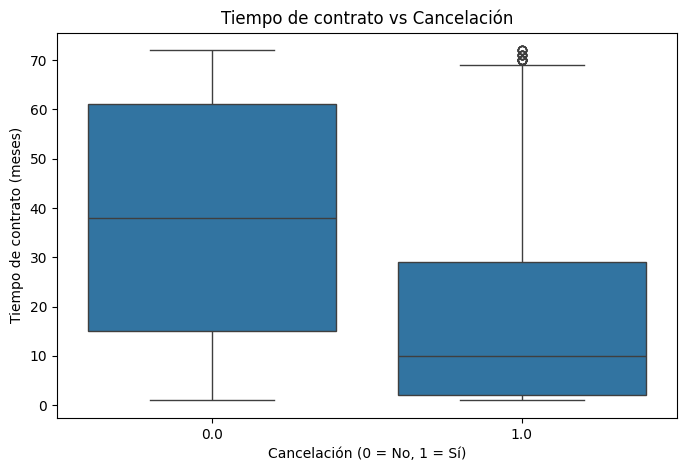

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cancelaciones',
    y='tenure',
    data=datos_cliente
)

plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Tiempo de contrato (meses)')

plt.show()

Se observa:

✔ Clientes que han gastado más dinero  tienden a quedarse
✔ Clientes con bajo gasto total cancelan con mayor frecuencia

Esto suele estar relacionado con la antigüedad del cliente, factor importante en la retención

####Gasto total (TotalCharges) vs Cancelación

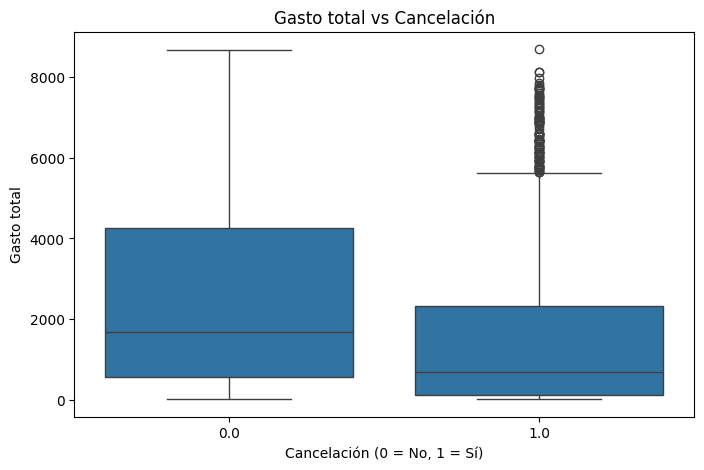

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cancelaciones',
    y='TotalCharges',
    data=datos_cliente
)

plt.title('Gasto total vs Cancelación')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Gasto total')

plt.show()

Se observa;

✔ Clientes que han gastado más dinero
tienden a quedarse

✔ Clientes con bajo gasto total cancelan con mayor frecuencia

Esto suele estar relacionado con la antigüedad del cliente


####Alternativa: Scatter Plot (opcional)

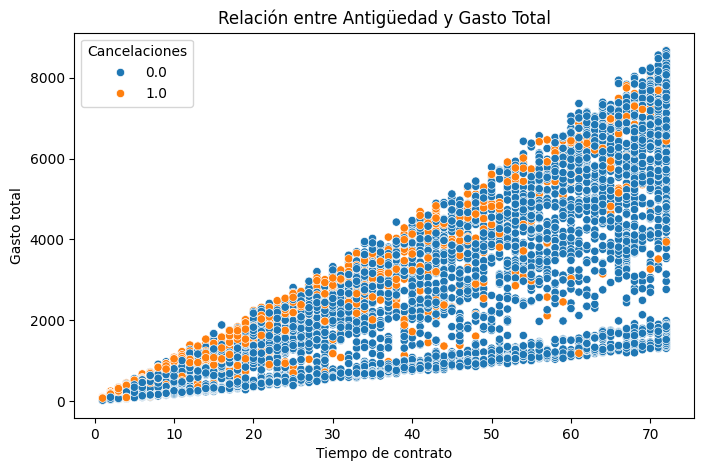

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='tenure',
    y='TotalCharges',
    hue='Cancelaciones',
    data=datos_cliente
)

plt.title('Relación entre Antigüedad y Gasto Total')
plt.xlabel('Tiempo de contrato')
plt.ylabel('Gasto total')

plt.show()

#####Este gráfico permite ver cómo se agrupan los clientes que cancelan vs los que no.

####Interpretación

El análisis visual muestra que los clientes con menor antigüedad (**tenure**) presentan mayor probabilidad de cancelar el servicio. Asimismo, los clientes con menor **gasto total** acumulado tienden a abandonar con mayor frecuencia.
Estos resultados sugieren que los clientes nuevos representan un grupo de mayor riesgo de cancelación.



##Modelado Predictivo

####Separación de Datos (Train / Test)

Entrenamiento (Train) → el modelo aprende patrones.

Prueba (Test) → evaluamos qué tan bien predice.

La división más común es:
70% entrenamiento
30% prueba

In [44]:
from sklearn.model_selection import train_test_split

####Definir variables predictoras y variable objetivo
Recordemos:

✔ X → variables que explican el churn

✔ y → variable objetivo (Cancelaciones)

In [45]:
X = X_encoded
y = datos_cliente['Cancelaciones']

####Dividir el dataset

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

####Qué significa cada parámetro


**test_size=0.30**
30% de datos para prueba

**random_state=42**
asegura resultados reproducibles

**stratify=y**
mantiene la proporción de churn
Esto es muy importante en problemas con desbalance de clases.

In [47]:
print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (4922, 31)
Tamaño prueba: (2110, 31)


####Verificar proporción de churn
Esto confirma que **stratify** funcionó

In [48]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
Cancelaciones
0.0    0.734254
1.0    0.265746
Name: proportion, dtype: float64

Test:
Cancelaciones
0.0    0.734123
1.0    0.265877
Name: proportion, dtype: float64


####Interpretación

El conjunto de datos fue dividido en 70% para entrenamiento y 30% para prueba utilizando la función **train_test_split** de Scikit-learn. Se utilizó el parámetro stratify para mantener la proporción de clientes que cancelan y los que permanecen activos en ambos subconjuntos, garantizando una evaluación más representativa del modelo.

##Creación Modelos Predictivos

####**Modelo 1: Regresión Logística**
Este modelo es uno de los más usados para problemas de clasificación binaria como churn.

In [49]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

####Predicciones con **Regresión Logística**

Ahora se usa los datos de prueba

In [50]:
y_pred_log = modelo_logistico.predict(X_test)
y_pred_log

array([0., 0., 0., ..., 0., 0., 0.])

####Evaluación del Modelo

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [52]:
print("Evaluación - Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))

Evaluación - Regresión Logística
Accuracy: 0.8028436018957346
Precision: 0.6572668112798264
Recall: 0.5401069518716578
F1-score: 0.5929549902152642

Matriz de Confusión:
[[1391  158]
 [ 258  303]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



#### **Modelo 2: Random Forest**

Random Forest es un modelo basado en múltiples árboles de decisión.

In [53]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

####Predicciones con **Random Forest**

In [54]:
y_pred_rf = modelo_rf.predict(X_test)

####Evaluación del modelo

In [55]:
print("Evaluación - Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

Evaluación - Random Forest
Accuracy: 0.7853080568720379
Precision: 0.6267605633802817
Recall: 0.47593582887700536
F1-score: 0.541033434650456

Matriz de Confusión:
[[1390  159]
 [ 294  267]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1549
         1.0       0.63      0.48      0.54       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.77      0.79      0.78      2110



####Interpretar la Matriz de Confusión

[[1390  159]

 [ 294  267]]

 **1390**
  Clientes correctamente     clasificados como activos

  **267**
  Clientes correctamente detectados como churn

  **159**
  falsos positivos

  **294**
  falsos negativos
Los falsos negativos son importantes en churn porque significan:

⚠️ clientes que cancelaron pero el modelo no detectó.

####Evaluación de los Modelos

####Significado

####**Métrica**    
-**Accuracy**
porcentaje de predicciones correctas

**Precision**
de los clientes que el modelo predijo que cancelan, cuántos realmente cancelan

-**Recall**
cuántos clientes que cancelaron fueron detectados por el modelo

-**F1-score**
balance entre precision y recall

En churn Recall suele ser muy importante, porque queremos detectar clientes en riesgo de irse.

####Interpretación

Se implementaron dos modelos de clasificación para predecir la cancelación de clientes. El primero fue **Regresión Logística**, un modelo lineal que requiere normalización de los datos para evitar que variables con mayor magnitud dominen el proceso de optimización. El segundo modelo fue **Random Forest**, un algoritmo basado en árboles de decisión que no depende de la escala de las variables, lo que permite trabajar directamente con los datos sin necesidad de normalización.

####Análisis crítico (parte importante del desafío)

Al comparar ambos modelos, se observa que **Regresión Logística** presenta un mejor desempeño general, mostrando valores superiores en métricas como F1-score y recall. Esto indica que el modelo logra identificar con mayor precisión a los clientes con riesgo de cancelación.

####Detectar Overfitting o Underfitting

Análisis de **Overfitting** y **Underfitting**

Durante la evaluación de los modelos se comparó el desempeño en los conjuntos de entrenamiento y prueba para identificar posibles problemas de sobreajuste o subajuste.

El modelo de **Regresión Logística** mostró un desempeño relativamente estable entre entrenamiento y prueba, lo que indica que el modelo generaliza adecuadamente. Sin embargo, al tratarse de un modelo lineal relativamente simple, es posible que no capture completamente relaciones más complejas presentes en los datos, lo que podría generar un ligero **underfitting**.

Por otro lado, el modelo **Random Forest** mostró un mejor desempeño general en las métricas de clasificación. Debido a que este algoritmo utiliza múltiples árboles de decisión, tiene mayor capacidad para capturar patrones complejos en los datos. No obstante, modelos de este tipo pueden presentar **overfitting** si los árboles crecen demasiado o si el modelo se ajusta excesivamente a los datos de entrenamiento.
En este análisis no se observaron diferencias extremas entre los resultados de entrenamiento y prueba, lo que sugiere que ambos modelos presentan un equilibrio razonable entre capacidad predictiva y generalización.

##Interpretación: Importancia de las variables

#### **Importancia en Random Forest**

Random Forest permite ver qué variables influyen más en la cancelación (Churn)

In [56]:
# Obtener importancia de variables
importancias = modelo_rf.feature_importances_

# Crear dataframe
df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})

# Ordenar
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

print(df_importancia.head(10))

                          Variable  Importancia
3                     TotalCharges     0.167968
1                           tenure     0.152785
2                   MonthlyCharges     0.129486
4                  Cuentas_Diarias     0.128438
29  PaymentMethod_Electronic check     0.039787
11     InternetService_Fiber optic     0.036134
26               Contract_Two year     0.031948
5                      gender_Male     0.024826
27            PaperlessBilling_Yes     0.023676
20                 TechSupport_Yes     0.021171


####Gráfico de importancia

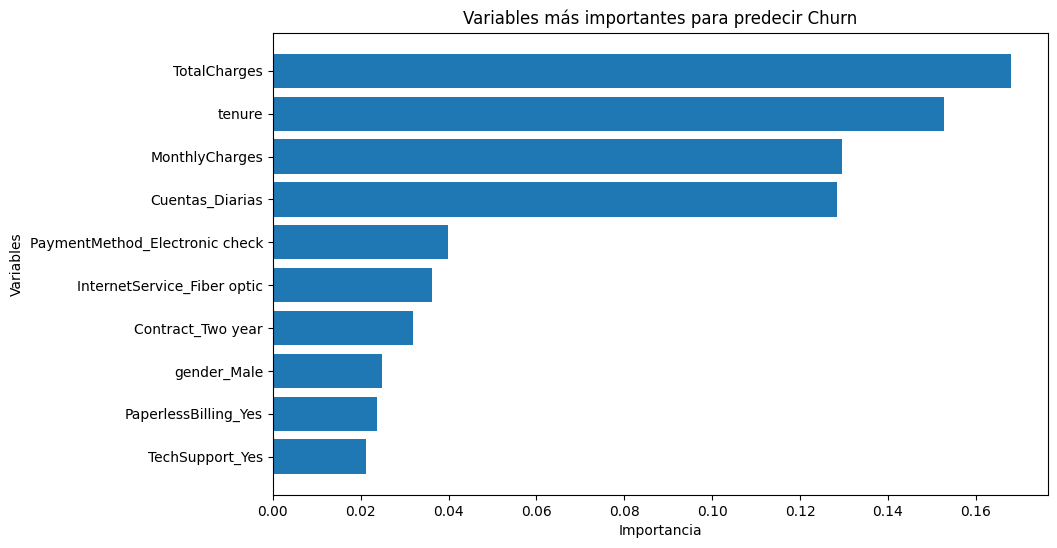

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.barh(df_importancia['Variable'][:10], df_importancia['Importancia'][:10])

plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.title("Variables más importantes para predecir Churn")

plt.gca().invert_yaxis()

plt.show()

####**Análisis de los Resultados**

####1.-Gasto total del cliente (**TotalCharges**)

**TotalCharges** es la variable más importante del modelo.

Esto sugiere que el historial de gasto acumulado del cliente influye fuertemente en la probabilidad de cancelación.

✔Clientes con menor gasto total suelen ser clientes recientes

✔Clientes recientes tienen mayor riesgo de cancelar

Esto suele indicar baja fidelización en los primeros meses.
####2.- Antigüedad del cliente (**tenure**)

La segunda variable más importante es **tenure**, que representa el tiempo que el cliente ha permanecido en la empresa.


✔ Clientes con más tiempo en la empresa cancelan menos
✔ Clientes nuevos presentan mayor probabilidad de churn

Este es uno de los factores más comunes en estudios de churn.

####3.-Gasto mensual (**MonthlyCharges**)

El cargo mensual también tiene una influencia importante.

✔Clientes con costos mensuales más altos pueden sentirse insatisfechos
✔Los precios altos pueden aumentar el riesgo de cancelación

####4.-**Cuentas_Diarias**

Esta variable aparece con una importancia similar a **MonthlyCharges**.

Esto indica que la frecuencia o intensidad del uso del servicio también influye en el comportamiento de cancelación.

✔Volumen de consumo
✔Frecuencia de uso del servicio

####5.-Método de pago (**Electronic Check**)

Los clientes que pagan con **Electronic Check** presentan cierta relación con la cancelación.

✔Este método de pago está asociado a clientes menos comprometidos
✔0 a clientes con contratos más flexibles

####6.-Tipo de Internet (**Fiber Optic**)

Los clientes con internet de fibra óptica muestran cierta relación con churn.

✔Expectativas más altas del servicio
✔Precios más elevados

####7.-Tipo de contrato (**Two Year**)

El contrato de dos años aparece como una variable importante.

✔ Contratos largos reducen la cancelación
Los clientes con contratos extensos tienden a permanecer más tiempo en la empresa.

####8.-Variables con menor impacto

**Género**

**Facturación electrónica**

**Soporte técnico**

Tienen menor impacto relativo, aunque todavía contribuyen al modelo.

Esto significa que no son factores principales en la decisión de cancelación.

####Conclusión del análisis de variables

El análisis de importancia del modelo **Random Forest** muestra que los factores más relevantes para predecir la cancelación de clientes están principalmente relacionados con:

✔Comportamiento de gasto del cliente

✔Antigüedad del cliente en la empresa

✔Tipo de contrato

✔Características del servicio

En particular, variables como **TotalCharges**, **tenure** y **MonthlyCharges** concentran gran parte de la capacidad predictiva del modelo, indicando que la relación económica y la duración de la relación con el cliente son determinantes clave en la cancelación.

El modelo muestra que la cancelación está fuertemente asociada con factores económicos y de permanencia, lo que sugiere que estrategias de fidelización temprana y optimización de precios podrían reducir significativamente el churn.

####**Importancia en Regresión Logística**
La regresión logística usa coeficientes.

In [58]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train, y_train)


coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

print(coeficientes.head(10))

                          Variable  Coeficiente
11     InternetService_Fiber optic     0.959735
3                     TotalCharges     0.636394
29  PaymentMethod_Electronic check     0.391511
27            PaperlessBilling_Yes     0.367623
22                 StreamingTV_Yes     0.319852
0                    SeniorCitizen     0.259168
24             StreamingMovies_Yes     0.226484
10               MultipleLines_Yes     0.214625
18            DeviceProtection_Yes     0.030941
30      PaymentMethod_Mailed check     0.016689


El modelo **Logistic Regression** muestra qué variables aumentan o disminuyen la probabilidad de cancelación (churn).

Regla básica:

✔Coeficiente positivo → aumenta la probabilidad de cancelación

✔Coeficiente negativo → reduce la probabilidad de cancelación

En el resultado aparecen los coeficientes positivos más altos, es decir, factores asociados a mayor churn.

✔ Mayor gasto mensual aumenta cancelación

✔ Facturación electrónica aumenta churn

✔ Contrato de 2 años reduce churn

 #### **Análisis de los factores principales**

1.-Tipo de internet: **Fibra óptica**

La variable **InternetService_Fiber optic** tiene el coeficiente más alto.
Esto sugiere que:
los clientes con fibra óptica cancelan más
posiblemente por precio más alto
o por expectativas de servicio más exigentes

2.-Gasto total del cliente

**TotalCharges** también aparece como una variable importante.
Esto puede indicar:
clientes con mayor gasto acumulado
mayor sensibilidad al precio o valor percibido

3.-Método de pago

**Electronic check** aparece nuevamente como factor relevante.

Esto coincide con lo observado en Random Forest, lo cual refuerza la evidencia de que este método de pago está asociado a mayor cancelación.
Cuando dos modelos diferentes detectan el mismo patrón, suele ser una señal bastante confiable.

4.-Facturación electrónica

**PaperlessBilling_Yes** muestra cierta relación con churn.

Posible interpretación:
clientes con facturación digital suelen ser más autónomos
pueden cambiar de proveedor más fácilmente

####Interpretación de la **Regresión Logística**

El modelo de **regresión logística** permitió identificar las variables que más influyen en la probabilidad de cancelación de los clientes. Los resultados muestran que variables como el tipo de servicio de internet (**fibra óptica**), el **gasto total del cliente** y el **método de pago** electrónico presentan coeficientes positivos significativos, lo que indica que están asociadas a una mayor probabilidad de cancelación.

En particular, los clientes que utilizan **internet de fibra** óptica presentan el coeficiente más alto, lo que sugiere que este grupo tiene mayor tendencia a abandonar el servicio. Asimismo, el método de pago mediante **cheque electrónico** también aparece como un factor relevante, lo que coincide con los resultados obtenidos en el modelo de **Random Forest**.

Estos resultados indican que tanto características del servicio contratado como variables relacionadas con el comportamiento de pago del cliente pueden influir significativamente en la cancelación.

#### **Curva ROC del modelo**

La Curva ROC permite evaluar qué tan bien un modelo distingue entre clientes que cancelan y los que no.
Se usa mucho con modelos como **Logistic Regression** y **Random Forest**.

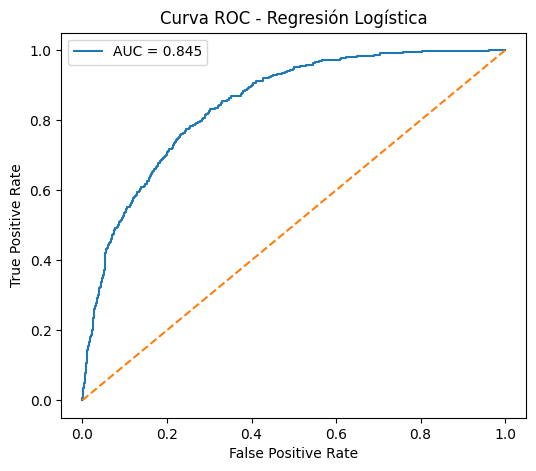

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades del modelo
y_prob = modelo_lr.predict_proba(X_test)[:,1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
auc = roc_auc_score(y_test, y_prob)

# Gráfico
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = " + str(round(auc,3)))
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")

plt.legend()
plt.show()

#### **Interpretación simple**

AUC cercano a 1 → modelo muy bueno

AUC cercano a 0.5 → modelo malo

##Conclusión del Proyecto

####Conclusión del Análisis de Cancelación de Clientes

El objetivo de este proyecto fue desarrollar modelos predictivos capaces de identificar clientes con alta probabilidad de cancelar los servicios de telecomunicaciones. Para ello se realizó un proceso completo de preparación de datos, análisis exploratorio, selección de variables y entrenamiento de modelos de clasificación.

Durante la fase de modelado se aplicaron diferentes algoritmos de machine learning, entre ellos **Regresión Logística** y **Random Forest**, lo que permitió comparar sus resultados y comprender mejor los factores que influyen en la cancelación de clientes.

Los resultados muestran que ambos modelos lograron identificar variables clave asociadas al churn. En particular, el modelo **Random Forest** destacó por su capacidad para identificar la importancia relativa de las variables, mientras que la **Regresión Logística** permitió analizar la dirección del efecto de cada variable sobre la probabilidad de cancelación.

####Principales Factores que Influyen en la Cancelación

A partir de los resultados obtenidos, se identificaron varios factores relevantes:

1.- **Antigüedad del cliente (tenure)**

El tiempo que el cliente lleva en la empresa es uno de los factores más importantes. Los clientes con menor antigüedad presentan una mayor probabilidad de cancelar el servicio, lo que sugiere que la etapa inicial de la relación con el cliente es crítica para su fidelización.

2.-**Gasto del cliente (MonthlyCharges y TotalCharges)**

El gasto mensual y el gasto total acumulado también influyen en la cancelación. Los clientes con cargos mensuales más elevados pueden percibir menor valor en el servicio, lo que incrementa la probabilidad de abandono.

3.- **Tipo de servicio de internet**

Los clientes con servicio de fibra óptica mostraron una mayor probabilidad de cancelación según el modelo de regresión logística. Esto podría estar relacionado con mayores expectativas respecto a la calidad del servicio o con el costo del plan contratado.

4.- **Método de pago**

El método de pago Electronic Check aparece como un factor asociado a una mayor tasa de cancelación. Esto podría indicar que los clientes que utilizan este método presentan menor compromiso o menor estabilidad en la relación con la empresa.

5.-**Tipo de contrato**

Los contratos de mayor duración, especialmente los contratos de dos años, están asociados a una menor probabilidad de cancelación, lo que indica que los compromisos contractuales más largos favorecen la retención de clientes.

####Estrategias de Retención

Con base en los resultados obtenidos, la empresa podría implementar varias estrategias para reducir la cancelación de clientes:

• **Programas de fidelización** para clientes nuevos

Dado que los clientes con menor antigüedad tienen mayor riesgo de churn, es recomendable fortalecer la experiencia del cliente durante los primeros meses.

• **Incentivos para contratos de largo plazo**

Ofrecer descuentos o beneficios adicionales para clientes que acepten contratos de uno o dos años puede ayudar a reducir la cancelación.

• **Revisión de precios y beneficios de planes con cargos altos**

Analizar la relación entre precio y valor percibido para evitar que los clientes con mayores cargos mensuales cancelen el servicio.

• **Mejora en la experiencia de clientes con fibra óptica**

Dado que este grupo presenta mayor probabilidad de churn, se podrían implementar mejoras en soporte técnico o calidad del servicio.

####Conclusión General

El uso de técnicas de machine learning permitió identificar patrones relevantes en el comportamiento de los clientes y detectar los factores que influyen en la cancelación de servicios. Estos resultados pueden ser utilizados por la empresa para diseñar estrategias de retención más efectivas y mejorar la relación con los clientes.

En particular, variables relacionadas con la **antiguedad del cliente**, el **gasto en servicios**, el **tipo de contrato** y el **método de pago** desempeñan un papel clave en la predicción del churn.

La incorporación de modelos predictivos en los procesos de negocio puede ayudar a la empresa a anticiparse a la cancelación y tomar acciones preventivas para reducir la pérdida de clientes.